In [6]:
#installing libraries
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
#loading apple stock data
df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
df.head()

/tmp/ipykernel_1662/3884349960.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.192602,24.659504,23.754466,24.648440,212818400
2015-01-05,23.511055,24.042129,23.325180,23.962467,257142000
2015-01-06,23.513277,23.772175,23.152589,23.575235,263188400
2015-01-07,23.842978,23.942553,23.610632,23.721273,160423600
2015-01-08,24.759085,24.816618,24.053199,24.170479,237458000


In [8]:
#analyze data
print(df.shape)
print(df.head())

(2264, 5)
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.192602  24.659504  23.754466  24.648440  212818400
2015-01-05  23.511055  24.042129  23.325180  23.962467  257142000
2015-01-06  23.513277  23.772175  23.152589  23.575235  263188400
2015-01-07  23.842978  23.942553  23.610632  23.721273  160423600
2015-01-08  24.759085  24.816618  24.053199  24.170479  237458000


In [9]:
#data preprocessing
df = df.dropna()
df["Target"] = df["Close"].shift(-1)
df = df.dropna()

In [11]:
#feature selection
X = df[["Open", "High", "Low", "Close", "Volume"]]
y = df["Target"]

In [12]:
#test train split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [14]:
#model training
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
#prediction
y_pred = model.predict(X_test)

In [16]:
#model evaluation
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 7.894228222654072
R2 Score: 0.9768263982277444


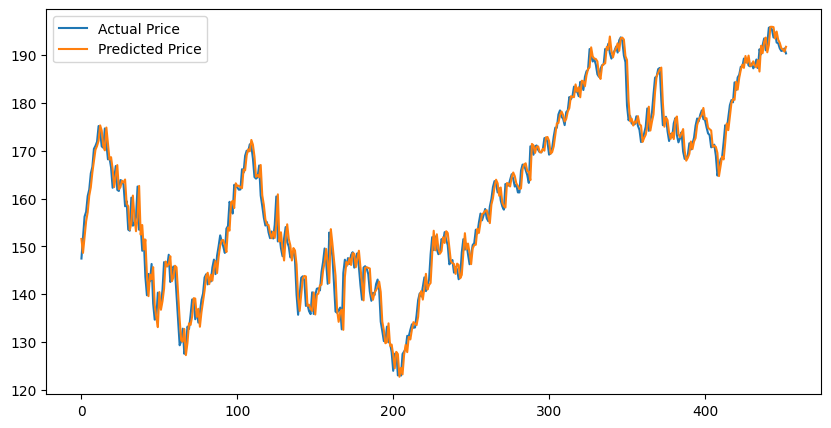

In [17]:
#visualization
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.show()